In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# 設定中文顯示，載入字體: msjh.ttc (微軟正黑體)
font_path = 'msjh.ttc'
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False    # 避免坐標軸負號顯示問題

In [2]:
# 生成資料
np.random.seed(42)
m = 100  # 筆數
X = 10 * np.random.rand(m, 1) - 5  # 隨機產生m筆X值
y = 0.5 * X ** 2 - X + 2 + np.random.randn(m, 1)  # 根據二次方程式計算y值

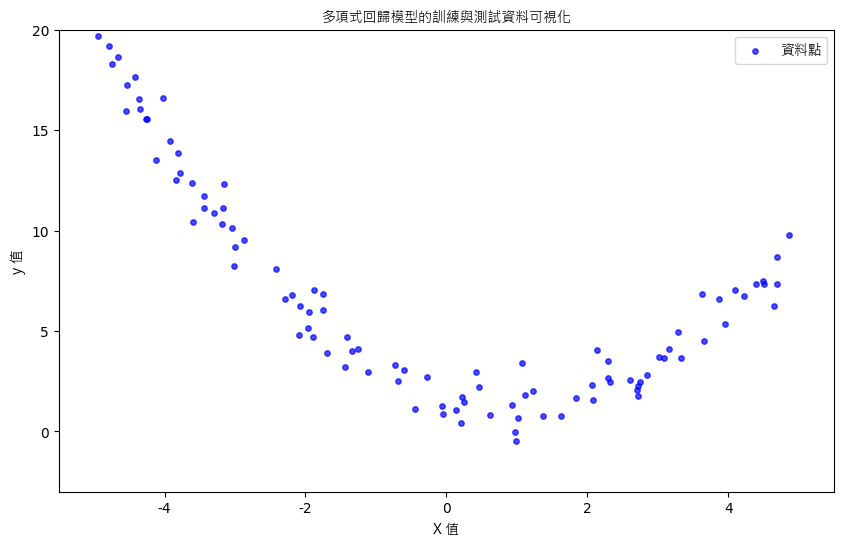

In [3]:
# 繪製x, y散佈圖, figuresize 調大
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="資料點", alpha=0.7, s=15)
plt.axis([-5.5, 5.5, -3, 20])

# 添加標題和標籤，全部加上 fontproperties=font_prop
plt.xlabel("X 值", fontproperties=font_prop)
plt.ylabel("y 值", fontproperties=font_prop)
plt.title("多項式回歸模型的訓練與測試資料可視化", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()

In [4]:
# 使用 train_test_split 將資料分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

# 使用 PolynomialFeatures 進行多項式轉換
poly_features = PolynomialFeatures(degree=16, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# 使用 PolynomialFeatures 進行多項式轉換
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_2 = poly_features_2.fit_transform(X_train)
X_test_poly_2 = poly_features_2.transform(X_test)

In [5]:
# 建立線性回歸模型並訓練
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 建立線性回歸模型並訓練
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train_poly_2, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


16次多項式回歸 - 訓練集 MSE: 0.69, 測試集 MSE: 17.04
2次多項式回歸 - 訓練集 MSE: 0.89, 測試集 MSE: 0.64


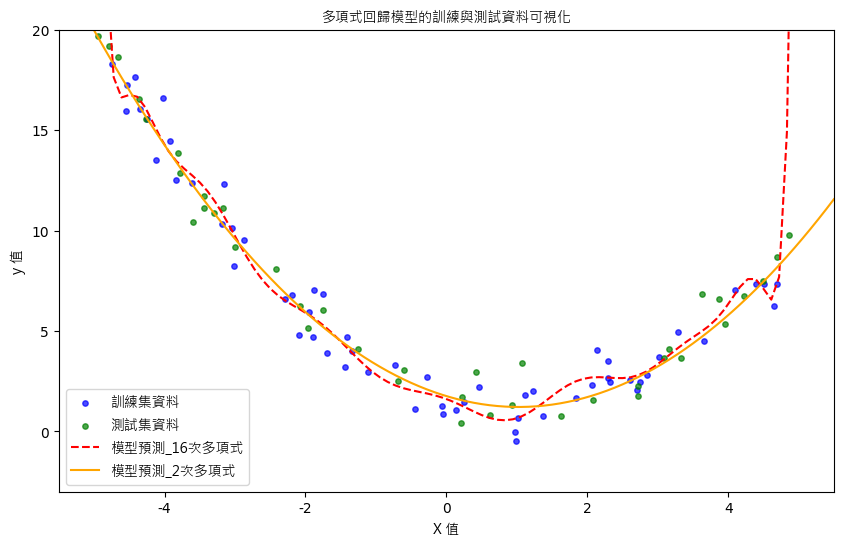

In [6]:
# 預測
y_train_pred = lin_reg.predict(X_train_poly)
y_test_pred = lin_reg.predict(X_test_poly)

# 計算均方誤差 (MSE)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 預測
y_train_pred_2 = lin_reg2.predict(X_train_poly_2)
y_test_pred_2 = lin_reg2.predict(X_test_poly_2)

# 計算均方誤差 (MSE)
train_mse_2 = mean_squared_error(y_train, y_train_pred_2)
test_mse_2 = mean_squared_error(y_test, y_test_pred_2)

print(f"16次多項式回歸 - 訓練集 MSE: {train_mse:.2f}, 測試集 MSE: {test_mse:.2f}")
print(f"2次多項式回歸 - 訓練集 MSE: {train_mse_2:.2f}, 測試集 MSE: {test_mse_2:.2f}")

# 可視化結果
plt.figure(figsize=(10, 6))

# 訓練集資料點
plt.scatter(X_train, y_train, color="blue", label="訓練集資料", alpha=0.7, s=15)
# 測試集資料點
plt.scatter(X_test, y_test, color="green", label="測試集資料", alpha=0.7, s=15)

# 預測曲線
X_plot = np.linspace(-5.5, 5.5, 100).reshape(100, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)
# 改成虛線
plt.plot(X_plot, y_plot, color="red", label="模型預測_16次多項式", linestyle="--")

# 預測曲線_2
X_plot_poly_2 = poly_features_2.transform(X_plot)
y_plot_2 = lin_reg2.predict(X_plot_poly_2)
plt.plot(X_plot, y_plot_2, color="orange", label="模型預測_2次多項式")

plt.axis([-5.5, 5.5, -3, 20])

# 添加標題和標籤，全部加上 fontproperties=font_prop
plt.xlabel("X 值", fontproperties=font_prop)
plt.ylabel("y 值", fontproperties=font_prop)
plt.title("多項式回歸模型的訓練與測試資料可視化", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()